### 실습 1. 전처리 데이터 불러오기

해야 할 일
먼저 Chapter 01에서 만든 CSV 파일을 pandas로 불러옵니다.
처음부터 단어를 분리하지 말고 데이터가 정상적으로 연결되는지 먼저 확인합니다.


In [1]:
import pandas as pd

# CSV 파일 불러오기
df_books = pd.read_csv("book_bestseller_clean.csv", encoding="utf-8-sig")

# 1. 전체 행과 컬럼 개수
print("1. 데이터 크기")
print(df_books.shape)

# 2. 컬럼 이름 확인
print("\n2. 컬럼 이름")
print(df_books.columns)

# 3. 앞의 5행 확인
print("\n3. 앞의 5행")
display(df_books.head())

# 4. '상품명' 컬럼이 존재하는지 확인
print("\n4. '상품명' 컬럼 존재 여부")
print("상품명" in df_books.columns)

1. 데이터 크기
(199, 8)

2. 컬럼 이름
Index(['순위', '판매상품ID', '상품명', '판매가', '저자', '출판사', '발행일', '분야'], dtype='str')

3. 앞의 5행


,순위,판매상품ID,상품명,판매가,저자,출판사,발행일,분야
0,1,S000000610612,소년이 온다,13500,한강,창비,2014-05-19,소설
1,2,S000001632467,모순,11700,양귀자,쓰다,2013-04-01,소설
2,3,S000216262757,결국 국민이 합니다,19800,이재명,오마이북,2025-04-15,정치/사회
3,4,S000216111714,혼모노,16200,성해나,창비,2025-03-28,소설
4,5,S000200550189,급류,12600,정대건,민음사,2022-12-22,소설



4. '상품명' 컬럼 존재 여부
True


### 실행 결과 요약

- `book_bestseller_clean.csv` 파일을 `df_books`로 정상적으로 불러왔다.
- 데이터는 **199행, 8개 컬럼**으로 구성되어 있다.
- `순위`, `판매상품ID`, `상품명`, `판매가`, `저자`, `출판사`, `발행일`, `분야` 컬럼이 포함되어 있다.
- 앞의 5행을 확인하여 데이터가 정상적으로 저장되어 있음을 확인하였다.
- `'상품명'` 컬럼의 존재 여부가 `True`로 출력되어 해당 컬럼이 존재함을 확인하였다.

### 실습 2. 분석할 도서 제목 확인하기

단어 분석을 시작하기 전에 상품명 데이터가 어떤 형태인지 직접 확인합니다.

In [2]:
# 1. 상품명 앞의 20개 확인
print("1. 상품명 앞의 20개")
display(df_books["상품명"].head(20))

# 2. 상품명 결측치 개수 확인
print("\n2. 상품명 결측치 개수")
print(df_books["상품명"].isna().sum())

# 3. 상품명을 문자열로 정리
titles = (
    df_books["상품명"]
    .fillna("")       # 결측치를 빈 문자열로 변경
    .astype(str)      # 문자열 자료형으로 변환
    .str.strip()      # 문자열 앞뒤 공백 제거
)

# 4. 정리된 상품명 앞의 5개 확인
print("\n3. 정리된 상품명 앞의 5개")
display(titles.head())

# 5. 비어 있는 제목 제외
titles = titles[titles != ""]

# 6. 최종 사용할 제목 개수 확인
print("\n4. 사용할 제목 개수")
print("사용할 제목 개수:", len(titles))


1. 상품명 앞의 20개


0                        소년이 온다
1                            모순
2                    결국 국민이 합니다
3                           혼모노
4                            급류
5                      초역 부처의 말
6                 청춘의 독서(특별증보판)
7                  어른의 행복은 조용하다
8                         채식주의자
9      단 한 번의 삶(강물에디션 활판인쇄 한정판)
10                     작별하지 않는다
11                          스토너
12           해커스 토익 기출 VOCA(보카)
13    다크 심리학(20만 부 한정판 스페셜 에디션)
14                 트렌드 코리아 2026
15                         위버멘쉬
16                          가공범
17                       듀얼 브레인
18         행동하지 않으면 인생은 바뀌지 않는다
19                  절창(화이트 에디션)
Name: 상품명, dtype: str


2. 상품명 결측치 개수
0

3. 정리된 상품명 앞의 5개


0        소년이 온다
1            모순
2    결국 국민이 합니다
3           혼모노
4            급류
Name: 상품명, dtype: str


4. 사용할 제목 개수
사용할 제목 개수: 199


### 실행 결과 요약

- 분석에 사용할 `상품명` 데이터를 확인하였다.
- `상품명` 컬럼의 **결측치는 0개**로 확인되었다.
- 상품명을 문자열로 변환하고 앞뒤 공백을 제거하여 분석하기 좋은 형태로 정리하였다.
- 비어 있는 제목을 제외한 결과, 최종적으로 사용할 수 있는 도서 제목은 **199개**이다.

### 실습 3. Dictionary로 단어 빈도 원리 이해하기

빈도 분석의 핵심은 매우 단순합니다.

같은 단어가 등장할 때마다 해당 단어의 숫자를 1씩 증가시키면 됩니다.
예를 들어 다음 단어가 있다고 가정합니다.


In [3]:
# 단어 목록
sample_words = [
    "데이터",
    "분석",
    "파이썬",
    "데이터",
    "AI",
    "분석",
    "데이터"
]

# 단어별 등장 횟수를 저장할 빈 Dictionary
word_counts = {}

# 단어를 하나씩 확인
for word in sample_words:
    if word in word_counts:
        word_counts[word] += 1   # 이미 있으면 1 증가
    else:
        word_counts[word] = 1    # 처음 나오면 1로 시작

# 결과 확인
print(word_counts)

{'데이터': 3, '분석': 2, '파이썬': 1, 'AI': 1}


### 실행 결과 요약

- Dictionary를 이용하여 각 단어의 등장 횟수를 계산하였다.
- `데이터`는 **3번**, `분석`은 **2번**, `파이썬`과 `AI`는 각각 **1번** 등장하였다.
- 처음 등장한 단어는 1로 저장하고, 이미 등장한 단어는 기존 값에 1을 더하는 방식으로 빈도를 계산하였다.
- 이를 통해 Dictionary의 `단어: 등장 횟수` 형태로 단어 빈도를 저장하는 원리를 확인하였다.

### 실습 4. Counter로 같은 작업 간단하게 처리하기

Python에는 빈도 계산을 도와주는 Counter가 있습니다.

In [4]:
# Counter 불러오기
from collections import Counter

# sample_words의 단어별 등장 횟수 계산
sample_counter = Counter(sample_words)

# 1. 전체 단어 빈도 확인
print("1. 전체 단어 빈도")
print(sample_counter)

# 2. 많이 등장한 순서대로 확인
print("\n2. 많이 등장한 순서")
print(sample_counter.most_common())

# 3. 가장 많이 등장한 상위 3개 확인
print("\n3. 상위 3개 단어")
print(sample_counter.most_common(3))

1. 전체 단어 빈도
Counter({'데이터': 3, '분석': 2, '파이썬': 1, 'AI': 1})

2. 많이 등장한 순서
[('데이터', 3), ('분석', 2), ('파이썬', 1), ('AI', 1)]

3. 상위 3개 단어
[('데이터', 3), ('분석', 2), ('파이썬', 1)]


### 실행 결과 요약

- `Counter`를 사용하여 단어별 등장 횟수를 간단하게 계산하였다.
- `데이터`가 **3번**으로 가장 많이 등장했고, `분석`이 **2번**, `파이썬`과 `AI`가 각각 **1번** 등장하였다.
- `most_common()`을 사용하면 빈도가 높은 단어부터 확인할 수 있다.
- `most_common(3)`을 사용하여 가장 많이 등장한 **상위 3개 단어**만 확인할 수 있었다.

### 실습 5. pandas value_counts()로 빈도 확인하기

pandas에서도 같은 값이 몇 번 등장했는지 쉽게 확인할 수 있습니다.

In [5]:
# sample_words를 pandas Series로 변환
sample_series = pd.Series(sample_words)

# 단어별 등장 횟수 확인
print("단어별 등장 횟수")
print(sample_series.value_counts())

단어별 등장 횟수
데이터    3
분석     2
파이썬    1
AI     1
Name: count, dtype: int64


### 실행 결과 요약

- `sample_words`를 pandas의 `Series`로 변환하였다.
- `value_counts()`를 사용하여 각 단어의 등장 횟수를 계산하였다.
- `데이터`는 **3번**, `분석`은 **2번**, `파이썬`과 `AI`는 각각 **1번** 등장하였다.
- pandas에서는 `value_counts()`를 이용해 값의 빈도를 간단하게 확인할 수 있음을 알 수 있었다.

### 실습 6. 실제 도서 제목을 간단하게 단어로 나누기

이제 실제 상품명 데이터를 사용합니다.
한글 형태소 분석을 사용하기 전에 먼저 정규표현식을 이용해 단순한 토큰화를 해봅니다.
이번 단계의 목적은 완벽한 단어 추출이 아니라 실제 데이터에서도 빈도 집계 흐름이 어떻게 연결되는지 확인하는 것입니다.

In [6]:
# 정규표현식을 사용하기 위해 re 모듈 불러오기
import re

# 문자열을 간단하게 단어로 나누는 함수 만들기
def simple_tokenize(text):
    # 영어는 소문자로 바꾸고,
    # 한글, 영어, 숫자가 연속된 부분만 찾아서 리스트로 반환
    return re.findall(r"[가-힣A-Za-z0-9]+", str(text).lower())


# 토큰화를 연습할 예시 제목
sample_title = "AI 시대의 데이터 분석, Python으로 시작하기!"

# 제목을 단어로 나누기
tokens = simple_tokenize(sample_title)

# 결과 확인
print(tokens)

['ai', '시대의', '데이터', '분석', 'python으로', '시작하기']


### 실행 결과 요약

- 정규표현식을 이용하여 문장을 간단한 단어 단위로 나누었다.
- 한글, 영어, 숫자로 이루어진 부분만 추출하고 공백과 특수문자는 제외하였다.
- 영어는 소문자로 변환하여 `AI`가 `ai`로 처리되었다.
- 단순 토큰화는 `시대의`, `python으로`처럼 의미 단위를 정확히 구분하지 못하는 한계가 있음을 확인하였다.

### 실습 7. 모든 제목에서 단어 추출하기

먼저 단순 토큰화 방식으로 모든 제목의 단어를 하나의 리스트에 모아봅니다.

In [7]:
# 모든 제목에서 추출한 단어를 저장할 빈 리스트
simple_words = []

# 제목을 하나씩 가져오기
for title in titles:
    
    # 하나의 제목을 단어로 나누기
    words = simple_tokenize(title)
    
    # 추출한 단어들을 simple_words에 추가
    simple_words.extend(words)

# 전체 단어 개수 확인
print("전체 단어 수:", len(simple_words))

# 앞의 50개 단어 확인
print("\n앞의 50개 단어:")
print(simple_words[:50])


# append()와 extend() 차이 확인
print("\n--- append()와 extend() 비교 ---")

example1 = []
example1.append(["데이터", "분석"])
print("append 결과:", example1)

example2 = []
example2.extend(["데이터", "분석"])
print("extend 결과:", example2)

전체 단어 수: 760

앞의 50개 단어:
['소년이', '온다', '모순', '결국', '국민이', '합니다', '혼모노', '급류', '초역', '부처의', '말', '청춘의', '독서', '특별증보판', '어른의', '행복은', '조용하다', '채식주의자', '단', '한', '번의', '삶', '강물에디션', '활판인쇄', '한정판', '작별하지', '않는다', '스토너', '해커스', '토익', '기출', 'voca', '보카', '다크', '심리학', '20만', '부', '한정판', '스페셜', '에디션', '트렌드', '코리아', '2026', '위버멘쉬', '가공범', '듀얼', '브레인', '행동하지', '않으면', '인생은']

--- append()와 extend() 비교 ---
append 결과: [['데이터', '분석']]
extend 결과: ['데이터', '분석']


### 실습 8. 실제 데이터에서 Counter로 빈도 확인하기

In [8]:
# 단어별 등장 횟수 계산
simple_counter = Counter(simple_words)

# 가장 많이 등장한 상위 30개 단어 확인
print("상위 30개 단어:")
print(simple_counter.most_common(30))

# 상위 30개를 DataFrame으로 변환
simple_top30 = pd.DataFrame(
    simple_counter.most_common(30),
    columns=["단어", "빈도"]
)

# 표 형태로 확인
display(simple_top30)

상위 30개 단어:
[('에디션', 12), ('부', 9), ('기념', 8), ('리커버', 8), ('한', 7), ('해커스', 7), ('위한', 7), ('말', 6), ('토익', 6), ('스페셜', 5), ('나는', 5), ('내가', 5), ('대하여', 4), ('싶은', 4), ('lc', 4), ('rc', 4), ('1', 4), ('단', 3), ('한정판', 3), ('않는다', 3), ('voca', 3), ('트렌드', 3), ('2026', 3), ('30만', 3), ('돈의', 3), ('때', 3), ('2025', 3), ('일본어', 3), ('없는', 3), ('필사', 3)]


,단어,빈도
0,에디션,12
1,부,9
2,기념,8
3,리커버,8
4,한,7
5,해커스,7
6,위한,7
7,말,6
8,토익,6
9,스페셜,5


### 실행 결과 요약

- `Counter`를 사용하여 실제 도서 제목에서 추출한 단어의 빈도를 계산하였다.
- `most_common(30)`을 이용하여 가장 많이 등장한 **상위 30개 단어**를 확인하였다.
- 결과를 DataFrame으로 변환하여 `단어`와 `빈도`를 표 형태로 확인하였다.
- 상위 단어를 살펴보면서 불필요한 단어나 추가 전처리가 필요한지 확인할 수 있다.

### 실습 9. pandas로도 실제 단어 빈도 확인하기

앞에서 만든 simple_words 리스트를 pandas Series로 변환합니다.

In [9]:
# simple_words를 pandas Series로 변환
simple_word_series = pd.Series(simple_words)

# pandas value_counts()로 상위 30개 단어 확인
print("1. pandas 상위 30개 단어")
print(simple_word_series.value_counts().head(30))

# Counter와 pandas 결과 비교
print("\n2. Counter 상위 10개")
print(simple_counter.most_common(10))

print("\n3. pandas 상위 10개")
print(simple_word_series.value_counts().head(10))

1. pandas 상위 30개 단어
에디션     12
부        9
기념       8
리커버      8
한        7
해커스      7
위한       7
말        6
토익       6
스페셜      5
나는       5
내가       5
대하여      4
싶은       4
lc       4
rc       4
1        4
단        3
한정판      3
않는다      3
voca     3
트렌드      3
2026     3
30만      3
돈의       3
때        3
2025     3
일본어      3
없는       3
필사       3
Name: count, dtype: int64

2. Counter 상위 10개
[('에디션', 12), ('부', 9), ('기념', 8), ('리커버', 8), ('한', 7), ('해커스', 7), ('위한', 7), ('말', 6), ('토익', 6), ('스페셜', 5)]

3. pandas 상위 10개
에디션    12
부       9
기념      8
리커버     8
한       7
해커스     7
위한      7
말       6
토익      6
스페셜     5
Name: count, dtype: int64


### 실행 결과 요약

- `simple_words`를 pandas의 `Series`로 변환하여 단어 빈도를 계산하였다.
- `value_counts()`를 사용하여 빈도가 높은 상위 30개 단어를 확인하였다.
- `Counter`와 `value_counts()`의 상위 10개 결과를 비교하였다.
- 두 방법에서 같은 단어의 빈도가 동일한지 확인하여 빈도 집계 결과를 검증하였다.

### 실습 10. 왜 형태소 분석이 필요한가?

한국어는 단순히 공백만 기준으로 단어를 나누기 어렵습니다.

예를 들어 다음과 같은 표현을 생각해 봅니다.

### 실습 11. Kiwi 형태소 분석기 설치하기

한글 형태소 분석 도구는 여러 가지가 있습니다.
이번 실습에서는 Windows 환경에서도 비교적 설치가 간단한 kiwipiepy를 사용합니다.
터미널에서 현재 사용하는 Python 가상환경이 활성화되어 있는지 확인한 뒤 설치합니다.

In [10]:
from kiwipiepy import Kiwi

kiwi = Kiwi()

print("kiwipiepy 사용 준비 완료")

kiwipiepy 사용 준비 완료


### 실습 12. Kiwi로 한 문장 품사 확인하기

In [11]:
# Kiwi 불러오기
from kiwipiepy import Kiwi

# Kiwi 형태소 분석기 만들기
kiwi = Kiwi()

# 분석해 볼 예시 문장
sample_title = "AI 시대의 데이터 분석을 위한 파이썬"

# 문장을 형태소 단위로 분석
tokens = kiwi.tokenize(sample_title)

# 전체 분석 결과 확인
print("전체 분석 결과:")
print(tokens)

# 각 단어와 품사 확인
print("\n단어별 품사:")
for token in tokens:
    print(token.form, token.tag)

전체 분석 결과:
[Token(form='AI', tag='SL', start=0, len=2), Token(form='시대', tag='NNG', start=3, len=2), Token(form='의', tag='JKG', start=5, len=1), Token(form='데이터', tag='NNG', start=7, len=3), Token(form='분석', tag='NNG', start=11, len=2), Token(form='을', tag='JKO', start=13, len=1), Token(form='위하', tag='VV', start=15, len=2), Token(form='ᆫ', tag='ETM', start=16, len=1), Token(form='파이썬', tag='NNP', start=18, len=3)]

단어별 품사:
AI SL
시대 NNG
의 JKG
데이터 NNG
분석 NNG
을 JKO
위하 VV
ᆫ ETM
파이썬 NNP


### 실습 14. 최소 글자수 필터링 적용하기

한 글자 단어가 모두 의미 없는 것은 아닙니다.

하지만 도서 제목 빈도 분석에서는 한 글자 토큰이 지나치게 많이 등장하면 결과를 해석하기 어려울 수 있습니다.

먼저 실제 결과를 확인한 뒤 이번 실습에서는 기본적으로 2글자 이상을 사용해 봅니다.

In [13]:
# 분석에 사용할 품사 지정
# NNG: 일반 명사, NNP: 고유 명사, SL: 영문
TARGET_TAGS = {"NNG", "NNP", "SL"}

# 명사 중심으로 단어를 추출하는 함수
def extract_words(text):
    result = []

    # 문장을 Kiwi로 형태소 분석
    for token in kiwi.tokenize(str(text)):

        # 원하는 품사만 선택
        if token.tag in TARGET_TAGS:
            
            # 앞뒤 공백 제거 + 영어 소문자로 통일
            word = token.form.strip().lower()

            # 결과 리스트에 단어 추가
            result.append(word)

    return result


# 함수 테스트
test_words = extract_words("AI 시대의 데이터 분석을 위한 파이썬")

print(test_words)

['ai', '시대', '데이터', '분석', '파이썬']


### 실습 15. 모든 도서 제목에서 명사 추출하기

In [14]:
# 모든 도서 제목에서 추출한 명사를 저장할 빈 리스트
filtered_words = []

# 제목을 하나씩 가져와 명사 중심으로 단어 추출
for title in titles:
    words = extract_words(title)
    filtered_words.extend(words)

# 추출 결과 확인
print("1. 추출된 전체 단어 수:", len(filtered_words))
print("\n2. 앞의 50개 단어")
print(filtered_words[:50])


# 추출된 단어의 빈도 계산
noun_counter = Counter(filtered_words)

# 빈도가 높은 상위 30개 단어 확인
print("\n3. 형태소 분석 후 상위 30개 단어")
print(noun_counter.most_common(30))


# 상위 30개 단어를 DataFrame으로 만들기
noun_top30 = pd.DataFrame(
    noun_counter.most_common(30),
    columns=["단어", "빈도"]
)

# 표로 확인
print("\n4. 형태소 분석 후 상위 30개 표")
display(noun_top30)


# 단순 토큰화 결과와 형태소 분석 결과 비교
print("\n5. 단순 토큰화 상위 10개")
display(simple_top30.head(10))

print("6. 형태소 분석 후 상위 10개")
display(noun_top30.head(10))

1. 추출된 전체 단어 수: 550

2. 앞의 50개 단어
['소년', '모순', '국민', '혼모', '노', '급류', '초역', '부처', '말', '청춘', '독서', '특별', '증보판', '어른', '행복', '채식주의자', '삶', '강물에디션', '활판', '인쇄', '한정판', '작별', '스토너', '해커스', '토익', '기출', 'voca', '보카', '다크', '심리학', '한정판', '스페셜', '에디션', '트렌드', '코리아', '위버멘쉬', '가공범', '듀얼', '브레인', '행동', '인생', '절창', '화이트', '에디션', '쇼펜하우어', '인생', '수업', '기념', '개정', '증보판']

3. 형태소 분석 후 상위 30개 단어
[('에디션', 14), ('기념', 10), ('말', 8), ('토익', 8), ('해커스', 7), ('리커버', 7), ('스페셜', 5), ('필사', 5), ('인생', 4), ('수업', 4), ('시대', 4), ('lc', 4), ('rc', 4), ('특별', 3), ('한정판', 3), ('voca', 3), ('트렌드', 3), ('남매', 3), ('돈', 3), ('때', 3), ('책', 3), ('일본어', 3), ('사람', 3), ('etf', 3), ('사랑', 3), ('어린이', 3), ('판', 3), ('세상', 3), ('공략', 3), ('소년', 2)]

4. 형태소 분석 후 상위 30개 표


,단어,빈도
0,에디션,14
1,기념,10
2,말,8
3,토익,8
4,해커스,7
5,리커버,7
6,스페셜,5
7,필사,5
8,인생,4
9,수업,4



5. 단순 토큰화 상위 10개


,단어,빈도
0,에디션,12
1,부,9
2,기념,8
3,리커버,8
4,한,7
5,해커스,7
6,위한,7
7,말,6
8,토익,6
9,스페셜,5


6. 형태소 분석 후 상위 10개


,단어,빈도
0,에디션,14
1,기념,10
2,말,8
3,토익,8
4,해커스,7
5,리커버,7
6,스페셜,5
7,필사,5
8,인생,4
9,수업,4


### 실행 결과 요약

- Kiwi 형태소 분석을 통해 전체 도서 제목에서 **550개의 단어**를 추출하였다.
- 형태소 분석 후 `에디션`, `기념`, `말`, `토익`, `해커스` 등의 단어가 높은 빈도로 나타났다.
- 단순 토큰화에서 나타났던 `부`, `한`, `위한` 같은 표현이 상위 단어에서 줄어들고, `필사`, `인생`, `수업` 등 의미를 파악하기 쉬운 단어가 나타났다.
- 다만 `에디션`, `기념`, `리커버`, `스페셜`처럼 도서의 주제보다는 상품 구성이나 홍보와 관련된 단어도 많이 나타나 추가 전처리가 필요해 보인다.

### 실습 16. 불용어 이해하기

In [15]:
# 1. 불용어 지정
stopwords = {
    "에디션",
    "기념",
    "리커버",
    "스페셜",
    "한정판"
}

# 2. 불용어를 제외한 단어만 새로운 리스트에 저장
clean_words = []

for word in filtered_words:
    if word not in stopwords:
        clean_words.append(word)

# 3. 불용어 제거 후 빈도 다시 계산
clean_counter = Counter(clean_words)

# 4. 제거 전 상위 20개 확인
print("불용어 제거 전")
print(noun_counter.most_common(20))

# 5. 제거 후 상위 20개 확인
print("\n불용어 제거 후")
print(clean_counter.most_common(20))

# 6. 전체 단어 수 비교
print("\n제거 전 단어 수:", len(filtered_words))
print("제거 후 단어 수:", len(clean_words))

불용어 제거 전
[('에디션', 14), ('기념', 10), ('말', 8), ('토익', 8), ('해커스', 7), ('리커버', 7), ('스페셜', 5), ('필사', 5), ('인생', 4), ('수업', 4), ('시대', 4), ('lc', 4), ('rc', 4), ('특별', 3), ('한정판', 3), ('voca', 3), ('트렌드', 3), ('남매', 3), ('돈', 3), ('때', 3)]

불용어 제거 후
[('말', 8), ('토익', 8), ('해커스', 7), ('필사', 5), ('인생', 4), ('수업', 4), ('시대', 4), ('lc', 4), ('rc', 4), ('특별', 3), ('voca', 3), ('트렌드', 3), ('남매', 3), ('돈', 3), ('때', 3), ('책', 3), ('일본어', 3), ('사람', 3), ('etf', 3), ('사랑', 3)]

제거 전 단어 수: 550
제거 후 단어 수: 511


### 실습 17. 불용어 목록 만들기

In [17]:
# 사용할 품사
# NNG: 일반 명사, NNP: 고유 명사, SL: 영문
TARGET_TAGS = {"NNG", "NNP", "SL"}

# 최소 단어 길이
MIN_LENGTH = 2

# 분석에서 제외할 불용어
STOPWORDS = {
    "세트",
    "개정판",
    "에디션",
    "리커버",
    "한정판",
}


# 명사 중심으로 단어를 추출하는 함수
def extract_words(text):
    result = []

    # Kiwi로 문장을 형태소 분석
    for token in kiwi.tokenize(str(text)):

        # 1. 원하는 품사가 아니면 제외
        if token.tag not in TARGET_TAGS:
            continue

        # 앞뒤 공백 제거 + 영어 소문자로 통일
        word = token.form.strip().lower()

        # 2. 2글자보다 짧으면 제외
        if len(word) < MIN_LENGTH:
            continue

        # 3. 불용어에 포함되어 있으면 제외
        if word in STOPWORDS:
            continue

        # 모든 조건을 통과한 단어만 추가
        result.append(word)

    return result


# 함수 테스트
test_words = extract_words("AI 시대의 데이터 분석 세트 리커버 한정판")

print(test_words)

['ai', '시대', '데이터', '분석']


### 실습 18. 최종 단어 목록 만들기

In [18]:
# 최종 단어를 저장할 빈 리스트
final_words = []

# 모든 도서 제목에서 조건에 맞는 단어 추출
for title in titles:
    final_words.extend(extract_words(title))

# 최종 단어 확인
print("1. 최종 단어 수:", len(final_words))
print("\n2. 앞의 50개 단어")
print(final_words[:50])


# 단어별 빈도 계산
final_counter = Counter(final_words)

print("\n3. 빈도 상위 30개")
print(final_counter.most_common(30))


# 상위 30개 단어를 DataFrame으로 만들기
top30 = pd.DataFrame(
    final_counter.most_common(30),
    columns=["단어", "빈도"]
)

print("\n4. 상위 30개 단어 표")
display(top30)


# CSV 파일로 저장
top30.to_csv(
    "chapter02_top30_words.csv",
    index=False,
    encoding="utf-8-sig"
)


# 파일이 실제로 생성되었는지 확인
from pathlib import Path

print("\n5. 파일 생성 여부")
print(Path("chapter02_top30_words.csv").exists())

1. 최종 단어 수: 438

2. 앞의 50개 단어
['소년', '모순', '국민', '혼모', '급류', '초역', '부처', '청춘', '독서', '특별', '증보판', '어른', '행복', '채식주의자', '강물에디션', '활판', '인쇄', '작별', '스토너', '해커스', '토익', '기출', 'voca', '보카', '다크', '심리학', '스페셜', '트렌드', '코리아', '위버멘쉬', '가공범', '듀얼', '브레인', '행동', '인생', '절창', '화이트', '쇼펜하우어', '인생', '수업', '기념', '개정', '증보판', '남매', '행복', '정도', '기념', '교보문고', '단독', '안녕']

3. 빈도 상위 30개
[('기념', 10), ('토익', 8), ('해커스', 7), ('스페셜', 5), ('필사', 5), ('인생', 4), ('수업', 4), ('시대', 4), ('lc', 4), ('rc', 4), ('특별', 3), ('voca', 3), ('트렌드', 3), ('남매', 3), ('일본어', 3), ('사람', 3), ('etf', 3), ('사랑', 3), ('어린이', 3), ('세상', 3), ('공략', 3), ('소년', 2), ('국민', 2), ('초역', 2), ('부처', 2), ('증보판', 2), ('어른', 2), ('행복', 2), ('기출', 2), ('보카', 2)]

4. 상위 30개 단어 표


,단어,빈도
0,기념,10
1,토익,8
2,해커스,7
3,스페셜,5
4,필사,5
5,인생,4
6,수업,4
7,시대,4
8,lc,4
9,rc,4



5. 파일 생성 여부
True


### 실습 19. 상위 단어를 막대그래프로 먼저 확인하기

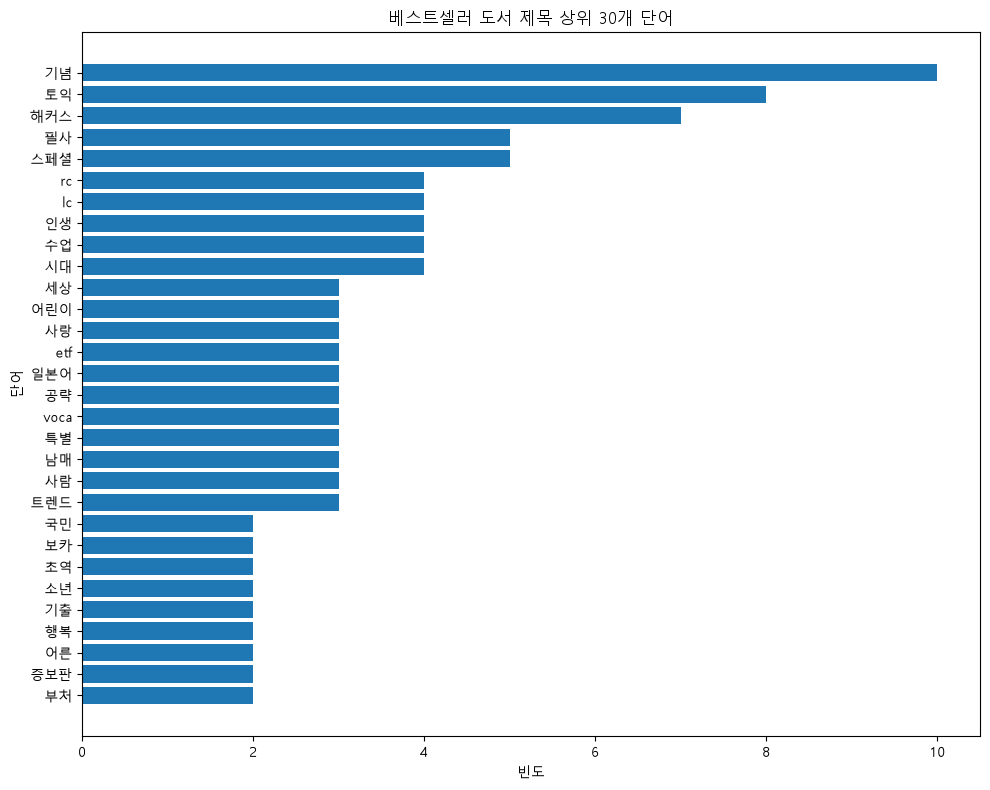

In [19]:
# 그래프를 그리기 위해 matplotlib 불러오기
import matplotlib.pyplot as plt

# Windows 한글 폰트 설정
plt.rcParams["font.family"] = "Malgun Gothic"

# 마이너스(-) 기호가 깨지는 현상 방지
plt.rcParams["axes.unicode_minus"] = False


# 빈도가 낮은 단어부터 정렬
# 가로 막대그래프에서 빈도가 높은 단어가 위쪽에 보이게 하기 위함
plot_data = top30.sort_values("빈도", ascending=True)


# 그래프 크기 설정
plt.figure(figsize=(10, 8))

# 가로 막대그래프 그리기
plt.barh(plot_data["단어"], plot_data["빈도"])

# 축 이름과 그래프 제목 설정
plt.xlabel("빈도")
plt.ylabel("단어")
plt.title("베스트셀러 도서 제목 상위 30개 단어")

# 글자가 잘리지 않도록 자동 조정
plt.tight_layout()

# 그래프 출력
plt.show()

### 실습 20. Word Cloud 설치하기

In [20]:
# Word Cloud 라이브러리 불러오기
from wordcloud import WordCloud

# 그래프 출력을 위한 matplotlib 불러오기
import matplotlib.pyplot as plt

print("WordCloud 사용 준비 완료")

WordCloud 사용 준비 완료
